## 📂 Load Datasets

In [25]:
import pandas as pd

orders = pd.read_csv('ecommerce_orders.csv')
sales = pd.read_csv('sales_data.csv')
tickets = pd.read_csv('ipl_ticket_sales.csv')
ipl = pd.read_csv('ipl_2023.csv')
ecom = pd.read_csv('ecommerce.csv')

orders.head()

,order_id,customer_name,city,product_category,amount,order_date
0,1,Qushi Ravi,Ahmedabad,Home,27833.92,2026-02-11 05:58:29.235123
1,2,Vidhi Rout,Hyderabad,Electronics,24890.04,2025-08-05 05:58:29.235123
2,3,Warjas Sachdeva,NaN,Electronics,64920.80,2024-10-28 05:58:29.235123
3,4,Ishaan Sahota,Chennai,Electronics,26617.52,2025-02-23 05:58:29.235123
4,5,Rushil Sundaram,Ahmedabad,Sports,59836.59,2025-10-07 05:58:29.235123


In [26]:
orders.shape

(200000, 6)

## 🔍 Basic EDA

In [27]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   order_id          200000 non-null  int64  
 1   customer_name     200000 non-null  object 
 2   city              193968 non-null  object 
 3   product_category  200000 non-null  object 
 4   amount            200000 non-null  float64
 5   order_date        200000 non-null  object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.2+ MB


In [28]:
orders.describe()

,order_id,amount
count,200000.000000,200000.000000
mean,100000.500000,49990.155807
std,57735.171256,28838.237520
min,1.000000,100.330000
25%,50000.750000,24948.335000
50%,100000.500000,50016.415000
75%,150000.250000,74961.892500
max,200000.000000,99999.930000


In [29]:
orders.isnull().sum()

,0
order_id,0
customer_name,0
city,6032
product_category,0
amount,0
order_date,0


## 📊 Category Analysis

In [30]:
orders['product_category'].value_counts()

,count
product_category,
Home,50175
Electronics,50118
Sports,49999
Accessories,49708


## 🔎 Filtering

In [31]:
orders[(orders['city']=='Mumbai') & (orders['amount']>5000)].head()

,order_id,customer_name,city,product_category,amount,order_date
20,21,Yochana Virk,Mumbai,Electronics,60722.09,2025-07-21 05:58:29.235123
23,24,Barkha Doshi,Mumbai,Accessories,69035.52,2024-09-04 05:58:29.235123
46,47,Daniel Mangal,Mumbai,Electronics,35037.18,2024-11-07 05:58:29.235123
69,70,Lohit Khare,Mumbai,Accessories,25431.69,2024-08-28 05:58:29.235123
74,75,Ubika Sengupta,Mumbai,Sports,90366.38,2025-08-20 05:58:29.235123


## 📈 GroupBy Analysis

In [32]:
tickets.groupby('city')['ticket_price'].sum().sort_values(ascending=False)

,ticket_price
city,
Chennai,44568066.35
Ahmedabad,44371980.41
Bangalore,44307871.80
Delhi,44221539.51
Mumbai,44213491.25
Kolkata,44209524.60
Surat,44153880.01
Hyderabad,44121278.91
Pune,44110375.81


## ⚡ Large Dataset Processing

In [33]:
chunks = pd.read_csv('sales_data.csv', chunksize=10000)
total_rows = sum(len(chunk) for chunk in chunks)
total_rows

1002000

## 📅 Date Feature Engineering

In [34]:
sales.head()

,date,product,city,revenue,quantity
0,2025-12-15 05:58:30.949988,Phone,Mumbai,39556.68,8
1,2025-04-16 05:58:30.949988,Smartwatch,Delhi,41376.50,7
2,2025-03-30 05:58:30.949988,Smartwatch,Delhi,39219.62,7
3,2025-12-31 05:58:30.949988,Laptop,Chennai,42894.91,2
4,2025-08-31 05:58:30.949988,Tablet,Surat,1936.26,6


In [35]:
sales['date'] = pd.to_datetime(sales['date'])
sales['day'] = sales['date'].dt.day_name()
sales['day'].value_counts()

,count
day,
Wednesday,145807
Saturday,143098
Friday,142947
Monday,142675
Thursday,142612
Tuesday,142553
Sunday,142308


## 🏏 IPL Analysis

In [36]:
ipl['winner'].value_counts()

,count
winner,
KKR,1265
DC,1263
SRH,1262
MI,1255
RR,1249
CSK,1243
RCB,1242
PBKS,1221


## 🛒 Ecommerce Analysis

In [37]:
ecom.groupby('category')['price'].mean().sort_values(ascending=False)

,price
category,
Home,75524.485463
Sports,75305.748738
Accessories,75292.514443
Electronics,75029.010375


## 🧹 Data Cleaning

In [38]:
ecom.fillna(method='ffill', inplace=True)
ecom.drop_duplicates(inplace=True)

/tmp/ipykernel_1344/511338035.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  ecom.fillna(method='ffill', inplace=True)


## 💾 Export Processed Data

In [39]:
orders.to_csv('processed_orders.csv', index=False)

## EDA

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Style set karo
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams['figure.figsize'] = (10, 6)

# ─── Data Load ───
df = pd.read_csv('ipl_2023.csv')

# ─── Quick Overview ───
print("Shape:", df.shape)               # (rows, columns)
print("\nFirst 5 rows:")
print(df.head())

print("\nColumn Info:")
print(df.info())                        # Dtypes + nulls

print("\nStatistical Summary:")
print(df.describe())                    # Mean, std, min, max

print("\nMissing Values:")
print(df.isnull().sum())               # Null counts per column

print("\nDuplicate Rows:", df.duplicated().sum())

Shape: (10000, 8)

First 5 rows:
   match_id team1 team2 winner         venue  runs  wickets  overs
0         1   CSK   RCB    SRH         Kotla    95        5   19.2
1         2   CSK   RCB     RR  Eden Gardens    89        4   18.0
2         3   KKR    DC     MI  Eden Gardens   235        1   15.3
3         4   KKR   KKR    RCB         Kotla   162        4   11.1
4         5    RR    RR    CSK         Kotla   212        8   16.9

Column Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   match_id  10000 non-null  int64  
 1   team1     10000 non-null  object 
 2   team2     10000 non-null  object 
 3   winner    10000 non-null  object 
 4   venue     10000 non-null  object 
 5   runs      10000 non-null  int64  
 6   wickets   10000 non-null  int64  
 7   overs     10000 non-null  float64
dtypes: float64(1), int64(3), object(4)
memory usage: 

## Univariate Analysis

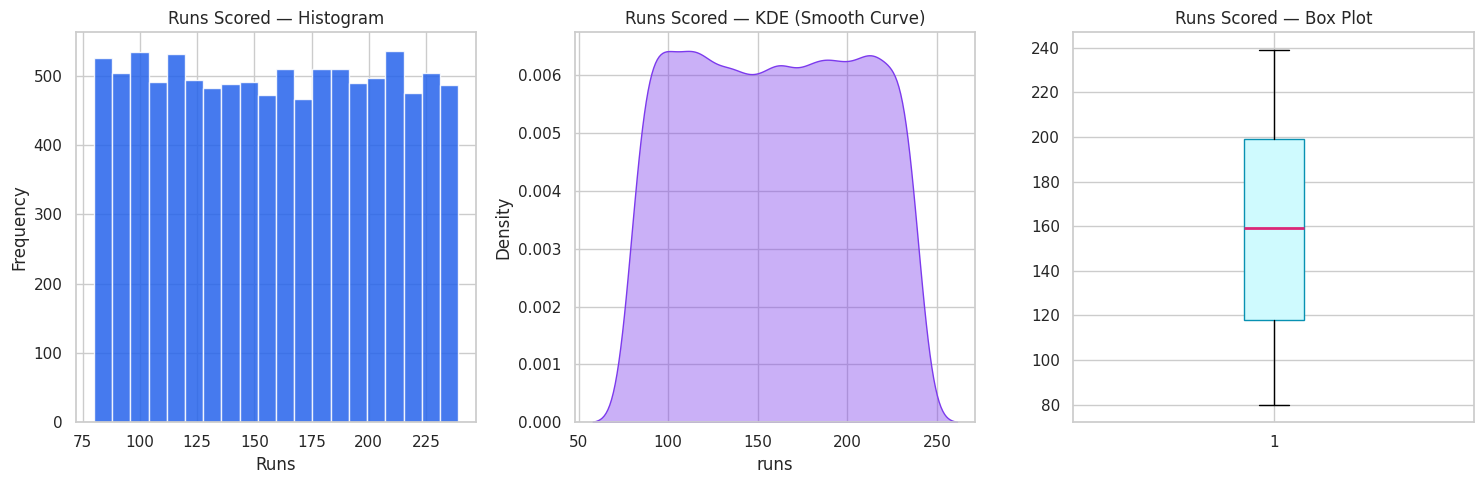

count    10000.000000
mean       159.034000
std         46.434535
min         80.000000
25%        118.000000
50%        159.000000
75%        199.000000
max        239.000000
Name: runs, dtype: float64
Skewness: 0.00
Kurtosis: -1.22


In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('ipl_2023.csv')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# ─── Histogram ───
axes[0].hist(df['runs'], bins=20, color='#2563eb', edgecolor='white', alpha=0.85)
axes[0].set_title('Runs Scored — Histogram')
axes[0].set_xlabel('Runs'); axes[0].set_ylabel('Frequency')

# ─── KDE Plot (Smooth distribution) ───
sns.kdeplot(df['runs'], ax=axes[1], color='#7c3aed', fill=True, alpha=0.4)
axes[1].set_title('Runs Scored — KDE (Smooth Curve)')

# ─── Box Plot (Outliers!) ───
axes[2].boxplot(df['runs'], patch_artist=True,
                boxprops=dict(facecolor='#cffafe', color='#0891b2'),
                medianprops=dict(color='#db2777', linewidth=2))
axes[2].set_title('Runs Scored — Box Plot')

plt.tight_layout()
plt.show()

# ─── Numerical Stats ───
print(df['runs'].describe())
print(f"Skewness: {df['runs'].skew():.2f}")
print(f"Kurtosis: {df['runs'].kurtosis():.2f}")

product_category
Home           50175
Electronics    50118
Sports         49999
Accessories    49708
Name: count, dtype: int64
product_category
Home           25.0875
Electronics    25.0590
Sports         24.9995
Accessories    24.8540
Name: proportion, dtype: float64


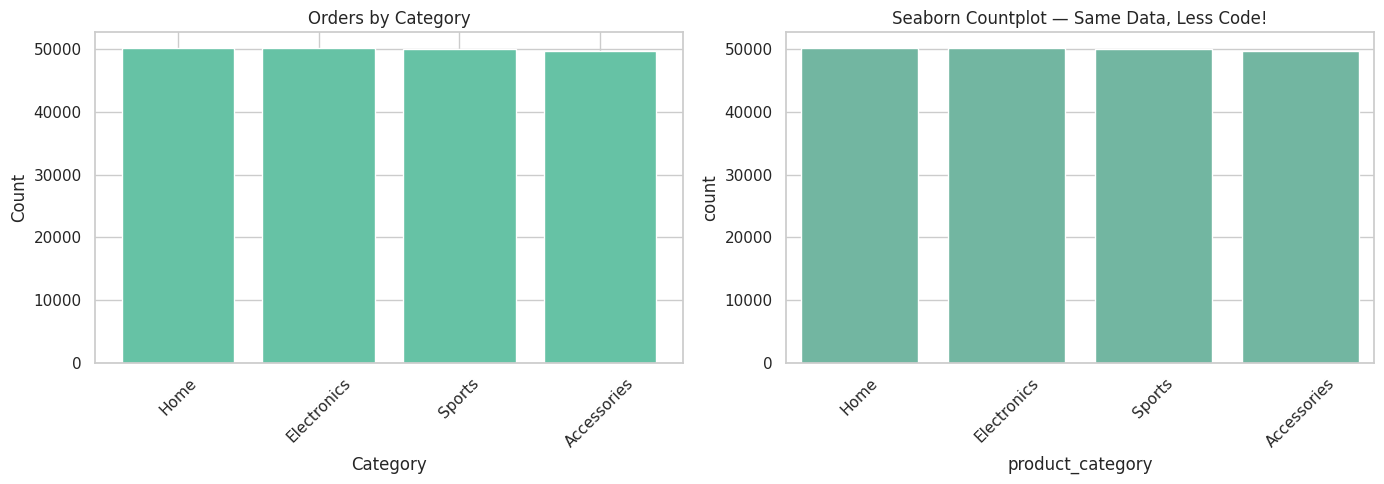

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('ecommerce_orders.csv')

# ─── Value Counts ───
print(df['product_category'].value_counts())
print(df['product_category'].value_counts(normalize=True) * 100)  # %

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ─── Bar Chart ───
category_counts = df['product_category'].value_counts()
axes[0].bar(category_counts.index, category_counts.values,)
axes[0].set_title('Orders by Category')
axes[0].set_xlabel('Category'); axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# ─── Seaborn Countplot (even easier!) ───
sns.countplot(data=df, x='product_category',
              order=df['product_category'].value_counts().index,
              ax=axes[1])
axes[1].set_title('Seaborn Countplot — Same Data, Less Code!')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Bivariate Analysis

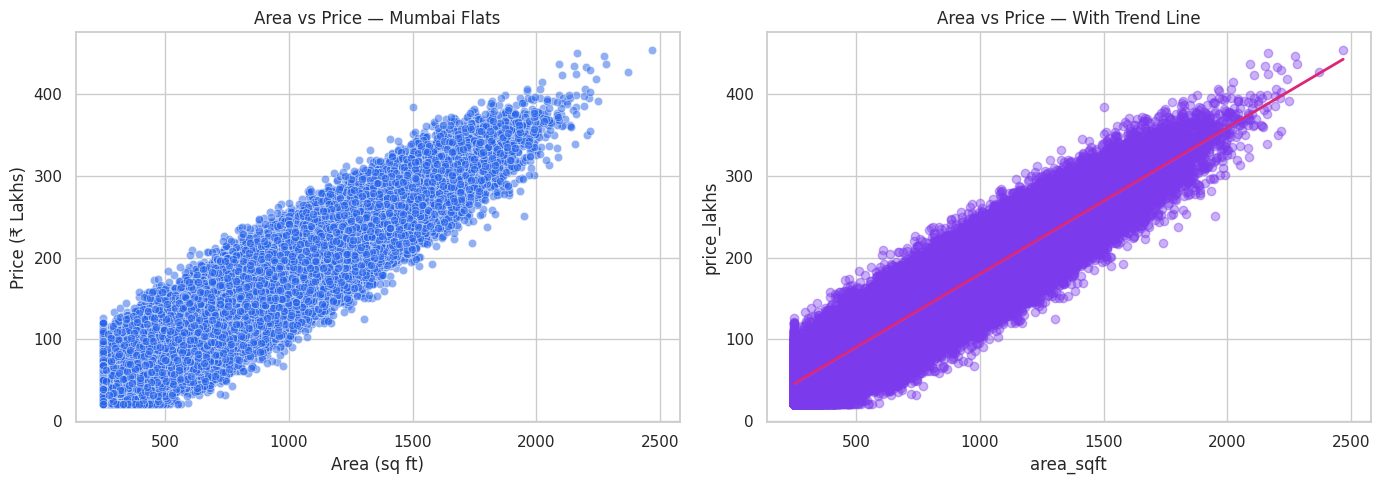

Pearson Correlation: 0.926


In [43]:
# Numerical vs Numerical — Scatter Plot & Correlation

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('mumbai_housing.csv')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ─── Scatter Plot ───
axes[0].scatter(df['area_sqft'], df['price_lakhs'],
                alpha=0.5, color='#2563eb', edgecolors='white', linewidth=0.5)
axes[0].set_xlabel('Area (sq ft)')
axes[0].set_ylabel('Price (₹ Lakhs)')
axes[0].set_title('Area vs Price — Mumbai Flats')

# ─── Seaborn regplot (scatter + regression line) ───
sns.regplot(data=df, x='area_sqft', y='price_lakhs',
            ax=axes[1], color='#7c3aed',
            scatter_kws={'alpha': 0.4},
            line_kws={'color': '#db2777', 'linewidth': 2})
axes[1].set_title('Area vs Price — With Trend Line')

plt.tight_layout(); plt.show()

# ─── Correlation value ───
corr = df['area_sqft'].corr(df['price_lakhs'])
print(f"Pearson Correlation: {corr:.3f}")   # 0.82 → Strong positive!

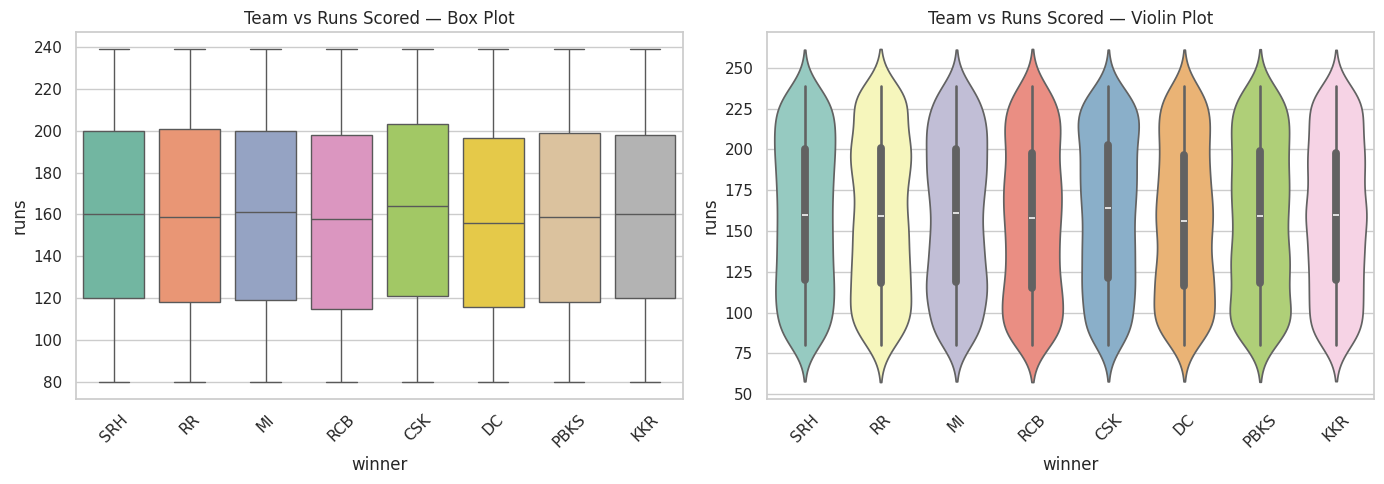

winner
CSK     161.626710
RR      159.905524
SRH     159.678288
MI      159.574502
KKR     159.493281
PBKS    158.158886
RCB     157.053140
DC      156.773555
Name: runs, dtype: float64


In [44]:
# Categorical vs Numerical — Box & Violin Plot

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('ipl_2023.csv')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ─── Box Plot — City vs Price ───
sns.boxplot(data=df, x='winner', y='runs',
            palette='Set2', ax=axes[0], hue='winner')
axes[0].set_title('Team vs Runs Scored — Box Plot')
axes[0].tick_params(axis='x', rotation=45)

# ─── Violin Plot (distribution ka shape bhi dikhta hai!) ───
sns.violinplot(data=df, x='winner', y='runs',
               palette='Set3', ax=axes[1], inner="box", hue="winner")
axes[1].set_title('Team vs Runs Scored — Violin Plot')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout(); plt.show()

# ─── Mean per group ───
print(df.groupby('winner')['runs'].mean().sort_values(ascending=False))

## Multivariate Analysis

             area_sqft  price_lakhs
area_sqft     1.000000     0.926458
price_lakhs   0.926458     1.000000


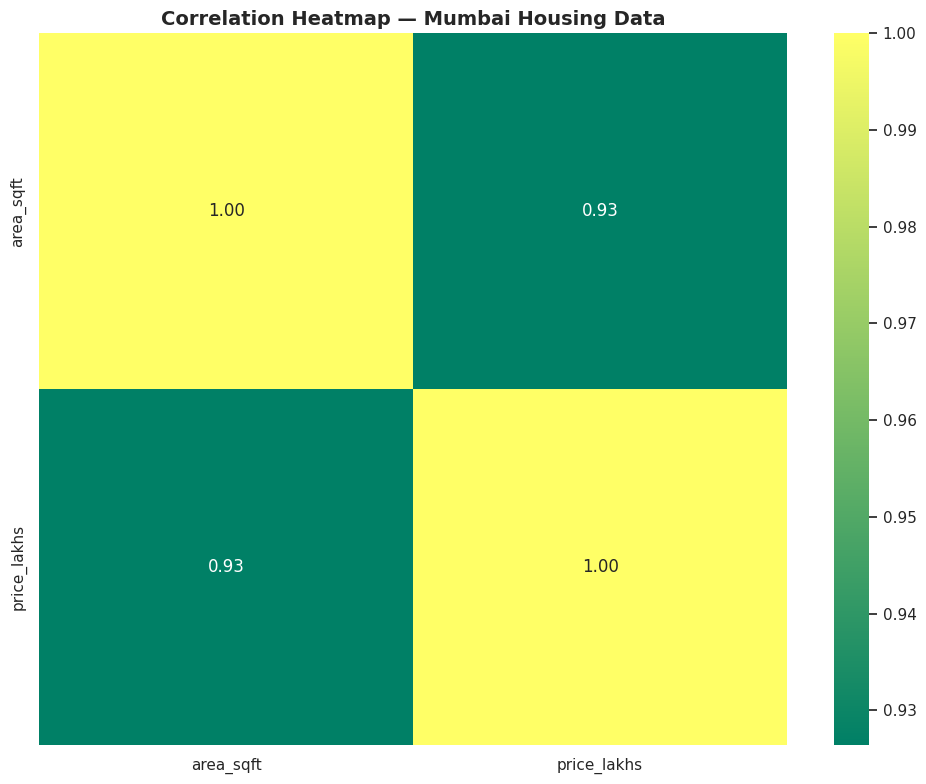

In [54]:
# Correlation Heatmap

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('mumbai_housing.csv')

# ─── Correlation Matrix ───
corr_matrix = df.select_dtypes(include='number').corr()
print(corr_matrix)

# ─── Heatmap ───
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,          # Numbers dikhao
    fmt='.2f',           # 2 decimal places
    cmap='summer',     # Red = positive, Blue = negative
)
plt.title('Correlation Heatmap — Mumbai Housing Data', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

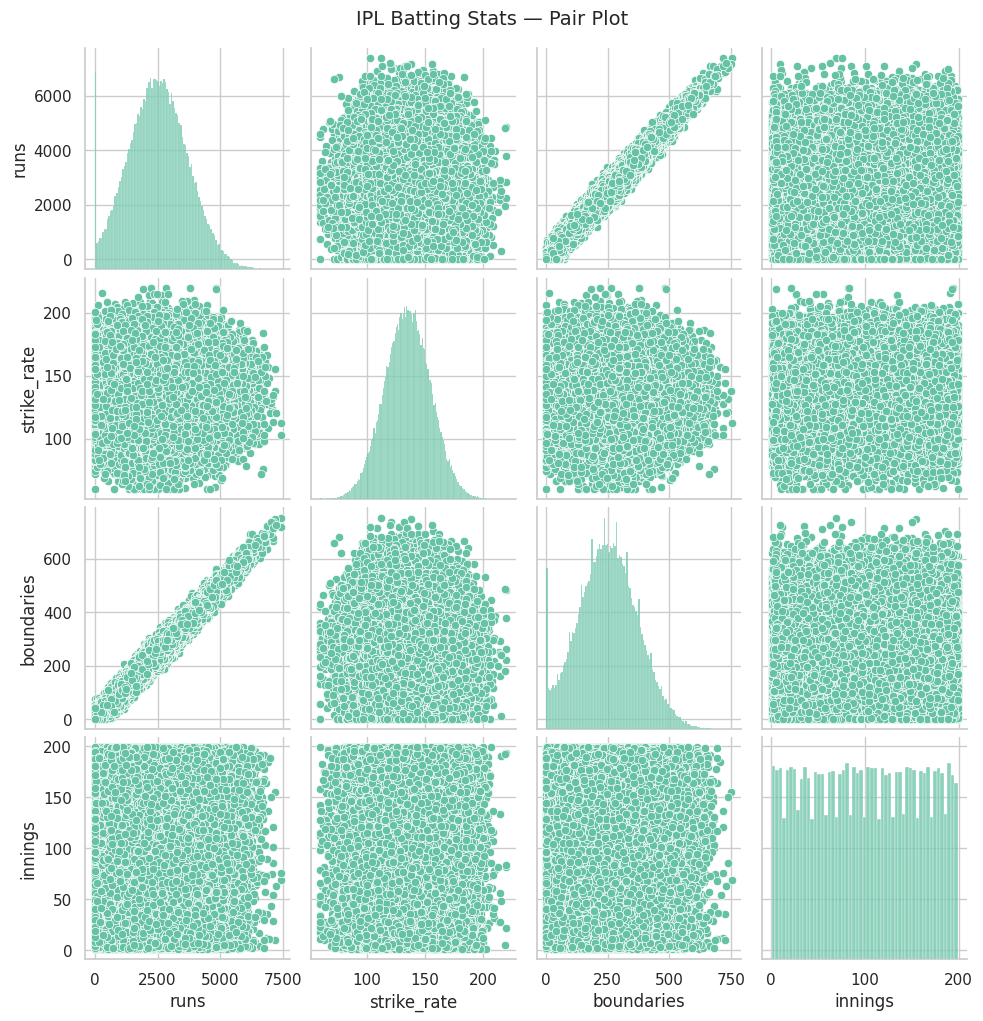

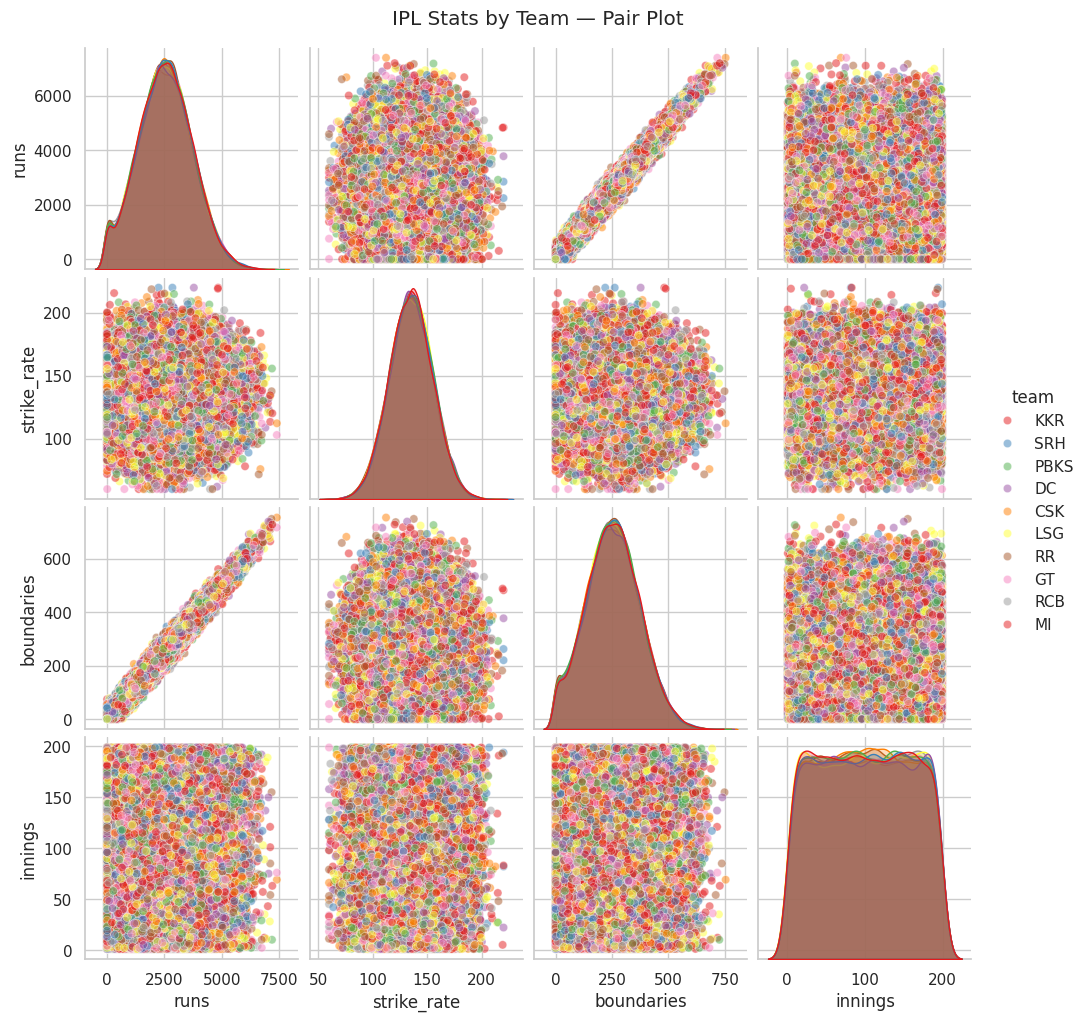

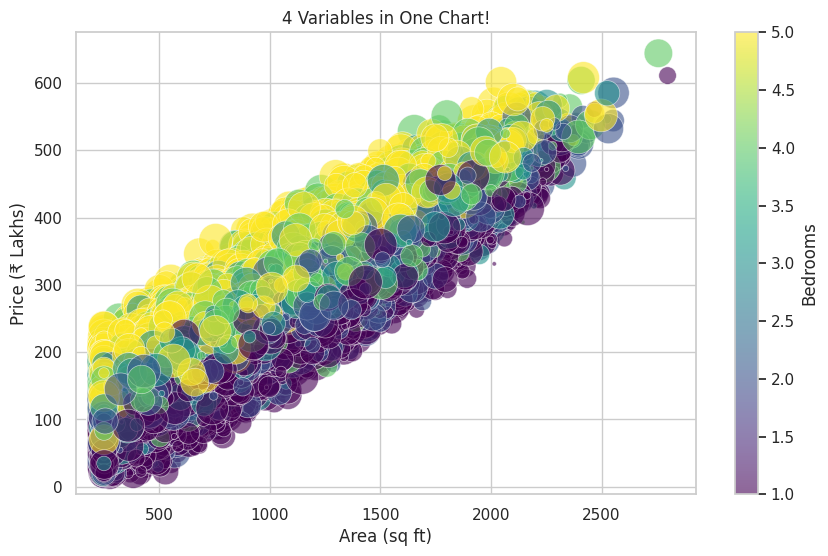

In [46]:
# Pair Plot

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('ipl_batting_stats.csv')

# ─── Basic Pairplot ───
sns.pairplot(df[['runs', 'strike_rate', 'boundaries', 'innings']])
plt.suptitle('IPL Batting Stats — Pair Plot', y=1.02, fontsize=14)
plt.show()

# ─── Advanced: Color by category ───
sns.pairplot(
    df[['runs', 'strike_rate', 'boundaries', 'innings', 'team']],
    hue='team',              # Har team ka alag color
    diag_kind='kde',         # Diagonal pe KDE plot
    plot_kws={'alpha': 0.5}, # Transparency
    palette='Set1'
)
plt.suptitle('IPL Stats by Team — Pair Plot', y=1.02)
plt.show()

# ─── 4-variable scatter (color + size) ───
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    df['area_sqft'], df['price_lakhs'],
    c=df['bedrooms'],        # 3rd variable = color
    s=df['floor'] * 10,     # 4th variable = size
    alpha=0.6, cmap='viridis', edgecolors='white', linewidth=0.5
)
plt.colorbar(scatter, label='Bedrooms')
plt.xlabel('Area (sq ft)'); plt.ylabel('Price (₹ Lakhs)')
plt.title('4 Variables in One Chart!')
plt.show()

## Pandas Profiling (ydata-profiling)

In [47]:
!pip install ydata_profiling

import pandas as pd
from ydata_profiling import ProfileReport

# ─── Data Load ───
df = pd.read_csv('ipl_2023.csv')

# ─── Poora EDA report ek line mein! ───
profile = ProfileReport(
    df,
    title="IPL 2023 — Full EDA Report",
    explorative=True      # Extra deep analysis
)

# ─── HTML file mein save karo ───
profile.to_file("ipl_eda_report.html")
print("Report saved! Browser mein kholo.")

# ─── Jupyter Notebook mein directly dikhao ───
profile.to_notebook_iframe()

# ─── Minimal report (bade datasets ke liye faster) ───
profile_minimal = ProfileReport(df, minimal=True)
profile_minimal.to_file("quick_report.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 8/8 [00:00<00:00, 22.54it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

...

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 8/8 [00:00<00:00, 59.41it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]